In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [ ]:
# すでにインストールされていれば不要
!pip install "quri-parts[pyscf,openfermion]"

In [3]:
from pyscf import gto, scf
from quri_parts.pyscf.mol import get_spin_mo_integrals_from_mole
from quri_parts.openfermion.mol import get_qubit_mapped_hamiltonian

distance = 1.0
mole = gto.M(
    atom=[["H", [0, 0, 0]],["H", [0, 0, distance]]],
    basis="sto-3g",
    spin=0, charge=0,
)
mf = scf.RHF(mole).run(verbose=0)
full_space, mo_eints = get_spin_mo_integrals_from_mole(mole, mf.mo_coeff)
jw_ham, _ = get_qubit_mapped_hamiltonian(full_space, mo_eints)

In [4]:
from quri_parts.core.operator import get_sparse_matrix
from scipy.sparse.linalg import eigsh

ham_matrix = get_sparse_matrix(jw_ham)
eigvals, _ = eigsh(ham_matrix, k=2, which="SA") # 最小固有値を2 つ求める
print(eigvals[0])

-1.1011503302326178


In [5]:
from quri_parts.circuit import UnboundParametricQuantumCircuit
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

n_qubits = 4
depth = 2

# 変分量子回路を作成
parametric_circ = UnboundParametricQuantumCircuit(n_qubits)
# 各レイヤーでゲートを追加
for d in range(depth):
    for i in range(n_qubits):
        parametric_circ.add_ParametricRY_gate(i)
    for i in range(n_qubits//2):
        parametric_circ.add_CZ_gate(2*i, 2*i+1)
    for i in range(n_qubits//2-1):
        parametric_circ.add_CZ_gate(2*i+1, 2*i+2)
# 最後にRY ゲートを追加
for i in range(n_qubits):
    parametric_circ.add_ParametricRY_gate(i)

# 変分量子回路を描画
draw_circuit(parametric_circ)

   ___             ___                     ___          
  |PRY|           |PRY|                   |PRY|         
--|0  |-----●-----|7  |-------------●-----|14 |---------
  |___|     |     |___|             |     |___|         
   ___     _|_             ___     _|_             ___  
  |PRY|   |CZ |           |PRY|   |CZ |           |PRY| 
--|1  |---|4  |-----●-----|8  |---|11 |-----●-----|15 |-
  |___|   |___|     |     |___|   |___|     |     |___| 
   ___             _|_     ___             _|_     ___  
  |PRY|           |CZ |   |PRY|           |CZ |   |PRY| 
--|2  |-----●-----|6  |---|9  |-----●-----|13 |---|16 |-
  |___|     |     |___|   |___|     |     |___|   |___| 
   ___     _|_     ___             _|_     ___          
  |PRY|   |CZ |   |PRY|           |CZ |   |PRY|         
--|3  |---|5  |---|10 |-----------|12 |---|17 |---------
  |___|   |___|   |___|           |___|   |___|         


In [6]:
import numpy as np
from quri_parts.core.state import quantum_state
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator

# 変分量子状態を作成
parametric_state = quantum_state(n_qubits, circuit=parametric_circ)

# コスト関数を定義
estimator = create_qulacs_vector_estimator()
def cost(theta_list: list[float]) -> float:
    state = parametric_state.bind_parameters(theta_list)
    return estimator(jw_ham, state).value.real

# 初期パラメータをランダムに生成
rng = np.random.default_rng(20250601)
theta_0 = rng.random(parametric_circ.parameter_count)
print(cost(theta_0))

-0.5832292364445311


In [7]:
from scipy.optimize import minimize
# 最適化の手法やパラメータ
method = "BFGS"
options = {"disp": True, "maxiter": 50, "gtol": 1e-6}

# 最適化の実行
cost_history = []
opt = minimize(
    cost, theta_0, method=method,
    callback=lambda x: cost_history.append(cost(x))
)

# 最終的なコスト関数の値と基底状態のエネルギーの差を表示
print(cost_history[-1] - eigvals[0])

1.0978817854834233e-10


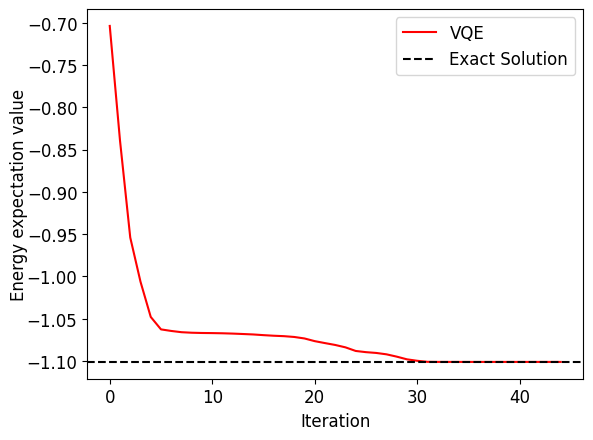

In [8]:
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12
plt.plot(cost_history, color="red", label="VQE")
plt.axhline(eigvals[0], linestyle="dashed", color="black", label="Exact Solution")
plt.xlabel("Iteration")
plt.ylabel("Energy expectation value", labelpad=-1)
plt.legend()
plt.show()